In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

In [28]:
data = pd.read_csv("fetal_health.csv")   # make sure file is in same folder
data.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [29]:
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

(2126, 22)

In [30]:
#Descriptive Statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


In [31]:
data.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

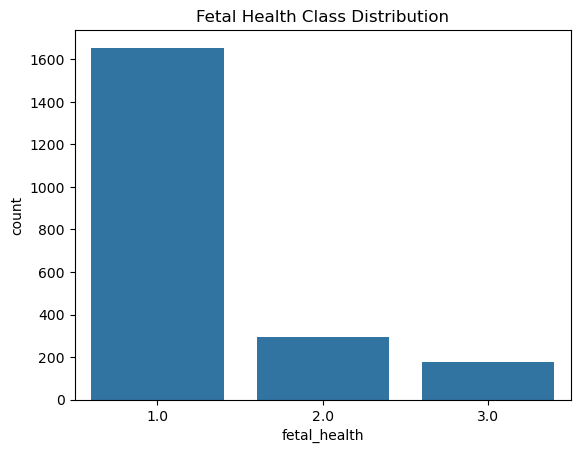

In [32]:
#Class Distribution
sns.countplot(x='fetal_health', data=data)
plt.title("Fetal Health Class Distribution")
plt.show()

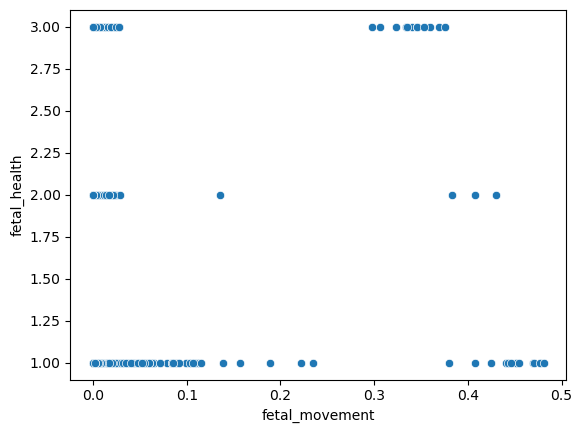

In [33]:
#Bivariate Analysis
sns.scatterplot(x=data['fetal_movement'], y=data['fetal_health'])
plt.show()

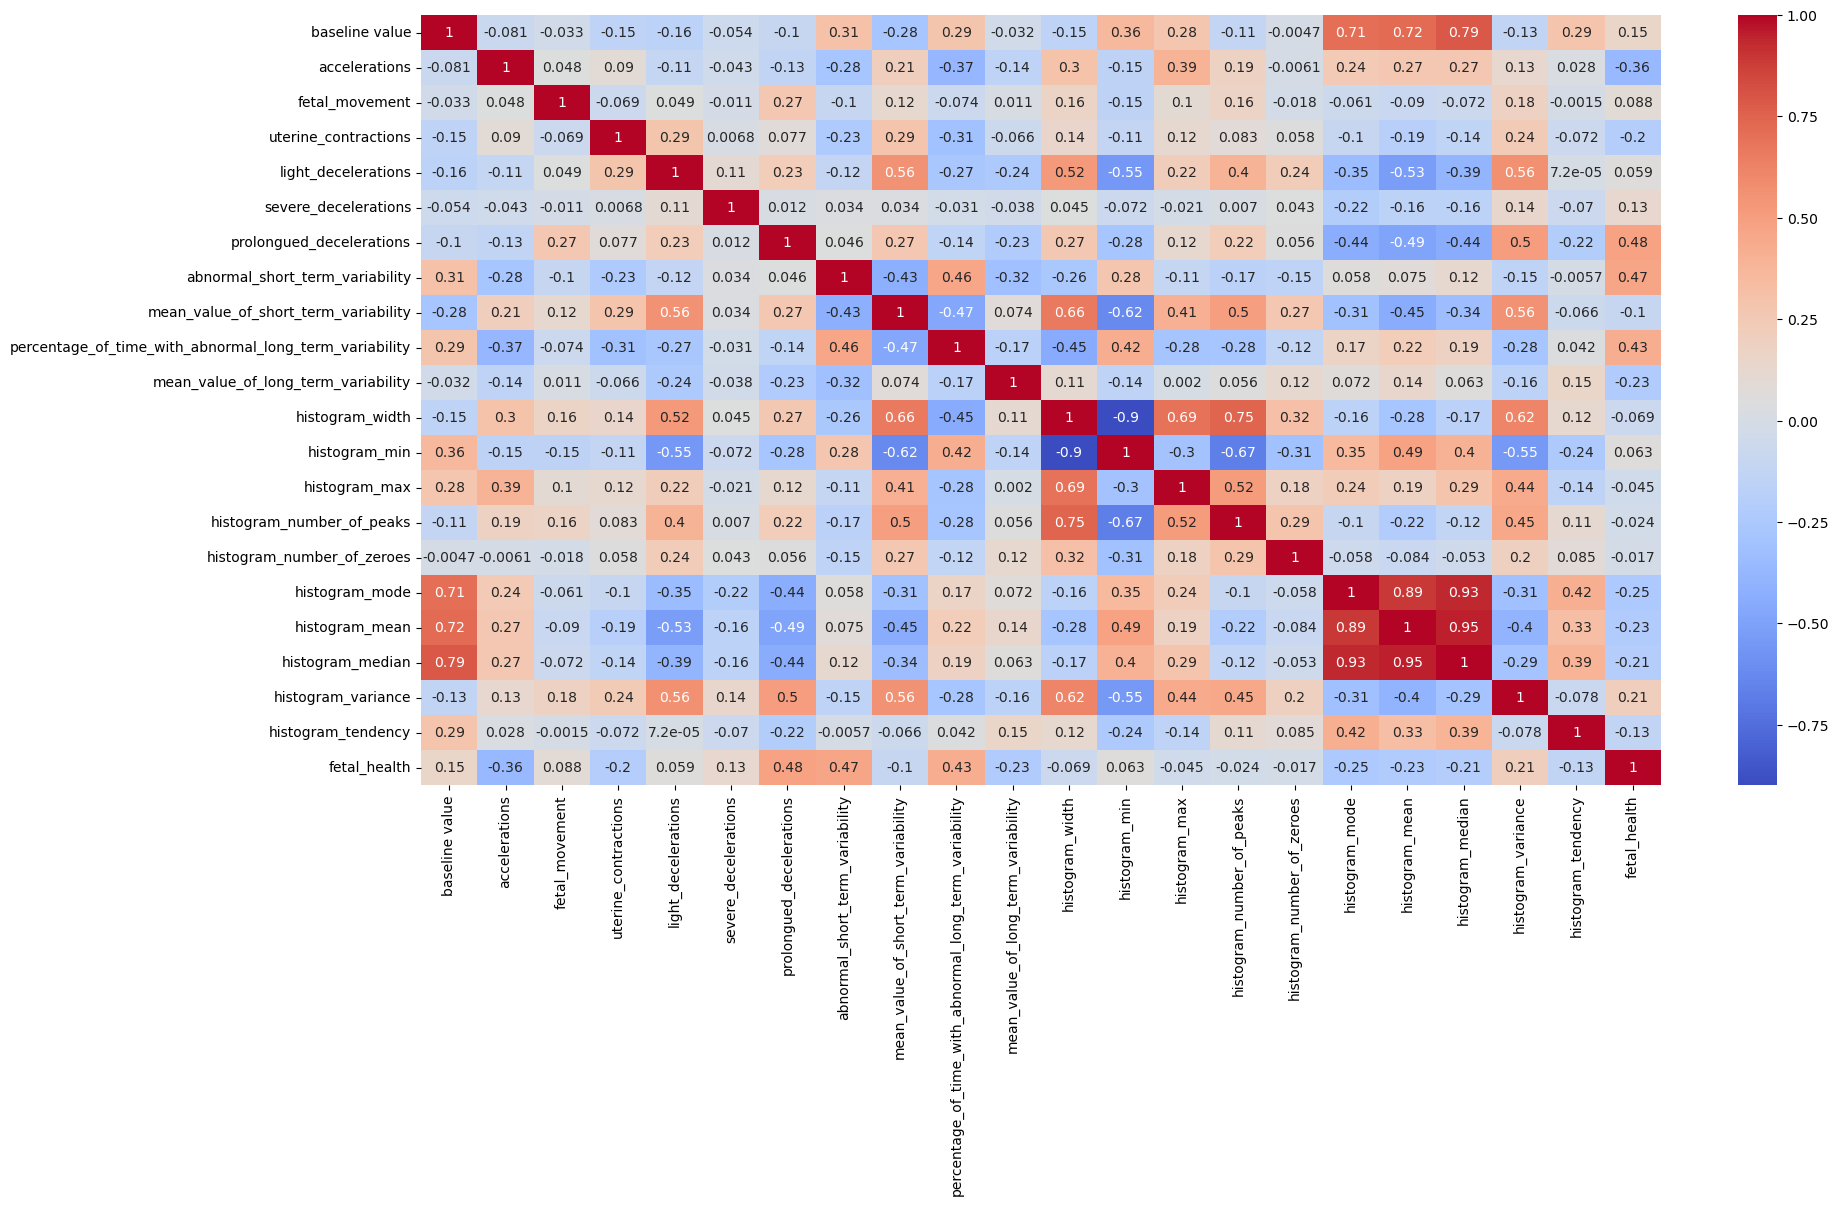

In [34]:
#Correlation Heatmap
plt.figure(figsize=(20,10))
corr = data.corr()
sns.heatmap(corr,annot=True, cmap='coolwarm')
plt.show()

In [35]:
#Feature Selection
data.corr()['fetal_health'].sort_values(ascending=False)

fetal_health                                              1.000000
prolongued_decelerations                                  0.484859
abnormal_short_term_variability                           0.471191
percentage_of_time_with_abnormal_long_term_variability    0.426146
histogram_variance                                        0.206630
baseline value                                            0.148151
severe_decelerations                                      0.131934
fetal_movement                                            0.088010
histogram_min                                             0.063175
light_decelerations                                       0.058870
histogram_number_of_zeroes                               -0.016682
histogram_number_of_peaks                                -0.023666
histogram_max                                            -0.045265
histogram_width                                          -0.068789
mean_value_of_short_term_variability                     -0.10

In [36]:
#Drop Unnecessary column
data.drop(columns=['histogram_mean'], axis=1, inplace=True)

In [37]:
selected_features = [
    'baseline value',
    'accelerations',
    'fetal_movement',
    'uterine_contractions',
    'light_decelerations',
    'severe_decelerations',
    'prolongued_decelerations',
    'abnormal_short_term_variability'
]

X = data[selected_features]
Y = data['fetal_health']

In [38]:
#Scling Data
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)
X_scaled.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability
0,0.259259,0.000000,0.0,0.000000,0.0,0.0,0.0,0.813333
1,0.481481,0.315789,0.0,0.400000,0.2,0.0,0.0,0.066667
2,0.500000,0.157895,0.0,0.533333,0.2,0.0,0.0,0.053333
3,0.518519,0.157895,0.0,0.533333,0.2,0.0,0.0,0.053333
4,0.481481,0.368421,0.0,0.533333,0.0,0.0,0.0,0.053333


In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)

(1488, 8) (638, 8)


In [40]:
smote = SMOTE()

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

from collections import Counter
print("Before SMOTE:", Counter(Y_train))
print("After SMOTE:", Counter(Y_train_smote))

Before SMOTE: Counter({1.0: 1159, 2.0: 194, 3.0: 135})
After SMOTE: Counter({1.0: 1159, 3.0: 1159, 2.0: 1159})


In [41]:
#Random Forest
RF_model = RandomForestClassifier()
RF_model.fit(X_train_smote, Y_train_smote)

rf_pred = RF_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(Y_test, rf_pred))

Random Forest Accuracy: 0.9012539184952978


In [42]:
#Decision Tree
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train_smote, Y_train_smote)

dt_pred = DT_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(Y_test, dt_pred))

Decision Tree Accuracy: 0.8714733542319749


In [43]:
#Logistic Regression
LR_model = LogisticRegression(max_iter=1000)
LR_model.fit(X_train_smote, Y_train_smote)

lr_pred = LR_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(Y_test, lr_pred))

Logistic Regression Accuracy: 0.7852664576802508


In [44]:
#KNN
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train_smote, Y_train_smote)

knn_pred = KNN_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(Y_test, knn_pred))

KNN Accuracy: 0.8479623824451411


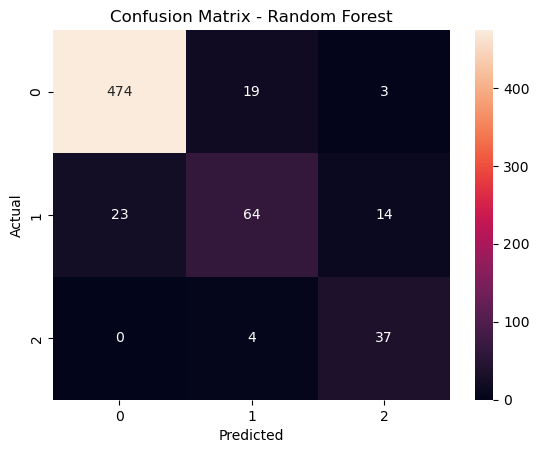

In [45]:
#Confusion Matrix
cm = confusion_matrix(Y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
print(classification_report(Y_test, rf_pred))

              precision    recall  f1-score   support

         1.0       0.95      0.96      0.95       496
         2.0       0.74      0.63      0.68       101
         3.0       0.69      0.90      0.78        41

    accuracy                           0.90       638
   macro avg       0.79      0.83      0.80       638
weighted avg       0.90      0.90      0.90       638



In [47]:
models = ['Random Forest', 'Decision Tree', 'Logistic Regression', 'KNN']
scores = [
    accuracy_score(Y_test, rf_pred),
    accuracy_score(Y_test, dt_pred),
    accuracy_score(Y_test, lr_pred),
    accuracy_score(Y_test, knn_pred)
]

df = pd.DataFrame({'Model': models, 'Accuracy': scores})
df

,Model,Accuracy
0,Random Forest,0.901254
1,Decision Tree,0.871473
2,Logistic Regression,0.785266
3,KNN,0.847962


In [48]:
import pickle

pickle.dump(RF_model, open('fetal_health_model.pkl', 'wb'))

In [49]:
sample = X_test.iloc[[0]]   # double brackets → keeps DataFrame
prediction = RF_model.predict(sample)

print("Predicted Class:", prediction)

Predicted Class: [1.]
